# ISAM2

## Overview

The `ISAM2` class in GTSAM is an incremental smoothing and mapping algorithm that efficiently updates the solution to a nonlinear optimization problem as new measurements are added. This class is particularly useful in applications such as SLAM (Simultaneous Localization and Mapping) where real-time performance is crucial.  

The algorithm is described in the 2012 IJJR paper by {cite:t}`http://dx.doi.org/10.1177/0278364911430419`. For background, also see the more recent booklet by {cite:t}`https://doi.org/10.1561/2300000043`.

This notebook focuses on the Python `ISAM2` API, including the inherited Bayes-tree query methods that expose the current linearized Gaussian structure.

## Key Features

- **Incremental Updates**: `ISAM2` allows for incremental updates to the factor graph, avoiding the need to solve the entire problem from scratch with each new measurement.
- **Nonlinear Optimization**: Capable of handling nonlinear systems, leveraging iterative optimization techniques to refine estimates.
- **Efficient Variable Reordering**: Dynamically reorders variables to maintain sparsity and improve computational efficiency.
- **Bayes-Tree Queries**: Exposes the current linearized Gaussian through marginal, joint, and Bayes-net queries that mirror the `GaussianBayesTree` interface.


<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/gtsam/nonlinear/doc/ISAM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import graphviz
from IPython.display import display
import numpy as np
import gtsam
from gtsam.symbol_shorthand import X

## Main Methods

### Initialization and Configuration

- **ISAM2 Constructor**: Initializes the `ISAM2` object with optional parameters for configuring the behavior of the algorithm, such as relinearization thresholds and ordering strategies.
- **size / empty**: Report the current Bayes-tree size after incremental updates.

### Updating the Graph

- **update**: Incorporates new factors and variables into the existing factor graph. This method performs the core incremental update, refining the solution based on new measurements.

### Accessing Results

- **calculateEstimate**: Retrieves the current estimate of the variables in the factor graph. This method can be called with specific variable keys to obtain their estimates.
- **marginalFactor / marginalInformation / marginalCovariance**: Query the current linearized Gaussian marginal for a single variable.
- **jointMarginalInformation / jointMarginalCovariance**: Materialize dense joint marginals for a set of keys.

### Inherited Bayes-Tree Queries

- **joint**: Extract a reduced Gaussian factor graph supported only on the queried variables.
- **jointBayesNet**: Extract the corresponding reduced Gaussian Bayes net.
- **numCachedSeparatorMarginals / deleteCachedShortcuts**: Inspect and clear shortcut caches created by Bayes-tree marginal queries.

### Advanced Features

- **getFactorsUnsafe**: Provides access to the internal factor graph, allowing for advanced manipulations and custom analysis.


## Example

We will build a small `Pose2` chain incrementally.

### Initialization and Configuration

In [3]:
prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))
odom_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.1, 0.1, 0.05]))

params = gtsam.ISAM2Params()
isam = gtsam.ISAM2(params)

### Updating the Graph

Below we do two updates.

In [4]:
new_factors = gtsam.NonlinearFactorGraph()
new_values = gtsam.Values()
new_factors.addPriorPose2(X(0), gtsam.Pose2(0.0, 0.0, 0.0), prior_noise)
new_values.insert(X(0), gtsam.Pose2(0.0, 0.0, 0.0))
isam.update(new_factors, new_values)

new_factors = gtsam.NonlinearFactorGraph()
new_values = gtsam.Values()
new_factors.add(gtsam.BetweenFactorPose2(X(0), X(1), gtsam.Pose2(1.0, 0.0, 0.0), odom_noise))
new_factors.add(gtsam.BetweenFactorPose2(X(1), X(2), gtsam.Pose2(1.0, 0.0, 0.0), odom_noise))
new_values.insert(X(1), gtsam.Pose2(1.0, 0.1, 0.02))
new_values.insert(X(2), gtsam.Pose2(2.0, -0.1, -0.01))
isam.update(new_factors, new_values)

  Reelimintated: 4  Relinearized: 0  Cliques: 3

### Visualizing the Bayes Tree

Because `ISAM2` inherits the Bayes-tree visualization methods, we can display the current tree structure directly with Graphviz.


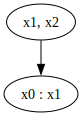

In [5]:
display(graphviz.Source(isam.dot()))


The Bayes tree inside `ISAM2` grows as updates are incorporated. The inherited `size()` and `empty()` methods are useful quick sanity checks.

In [6]:
print("empty:", isam.empty())
print("number of cliques:", isam.size())


empty: False
number of cliques: 2


### Accessing Results

`calculateEstimate` retrieves all current nonlinear estimates. This can be expensive if there are many variables.

In [7]:

estimate = isam.calculateEstimate()
estimate


Values with 3 values:
Value x0: (gtsam::Pose2)
(-5.45184e-18, 5.45184e-17, 5.59787e-17)

Value x1: (gtsam::Pose2)
(1.002, 1.99993e-05, 6.2117e-17)

Value x2: (gtsam::Pose2)
(2.0044, -7.4327e-05, 7.01666e-17)


### Accessing Single-Variable Results

For a single key, `ISAM2` exposes the templated `calculateEstimate`. We can also examine the conditional returned by `marginalFactor`, as well as the corresponding dense information and covariance matrices. These are exact for the current linearized Gaussian represented by the Bayes tree.

In [8]:
print("x1 estimate:", isam.calculateEstimatePose2(X(1)))

x1_factor = isam.marginalFactor(X(1))
x1_information = isam.marginalInformation(X(1))
x1_covariance = isam.marginalCovariance(X(1))

print(type(x1_factor).__name__)
print("information shape:", x1_information.shape)
print("covariance shape:", x1_covariance.shape)
np.round(x1_covariance, 4)


x1 estimate: (1.002, 1.99993e-05, 6.2117e-17)

GaussianConditional
information shape: (3, 3)
covariance shape: (3, 3)


array([[ 0.0501, -0.0008, -0.0008],
       [-0.0008,  0.06  ,  0.01  ],
       [-0.0008,  0.01  ,  0.0125]])

### Accessing Joint Marginals

Dense joint information and covariance can be requested directly. The returned `JointMarginal` provides both the full matrix and keyed block access.


In [9]:
query_keys = [X(2), X(0)]
joint_information = isam.jointMarginalInformation(query_keys)
joint_covariance = isam.jointMarginalCovariance(query_keys)

print("joint information shape:", joint_information.fullMatrix().shape)
print("cross block shape:", joint_covariance.at(X(2), X(0)).shape)
np.round(joint_covariance.fullMatrix(), 4)


joint information shape: (6, 6)
cross block shape: (3, 3)


array([[ 0.04  ,  0.    ,  0.    ,  0.04  ,  0.0004,  0.    ],
       [ 0.    ,  0.04  , -0.    , -0.0004,  0.04  , -0.    ],
       [ 0.    , -0.    ,  0.01  ,  0.0008,  0.02  ,  0.01  ],
       [ 0.04  , -0.0004,  0.0008,  0.0602,  0.0021,  0.0013],
       [ 0.0004,  0.04  ,  0.02  ,  0.0021,  0.1025,  0.0225],
       [ 0.    , -0.    ,  0.01  ,  0.0013,  0.0225,  0.015 ]])

### Inherited Bayes-Tree Query Methods

The inherited `joint` and `jointBayesNet` methods expose the reduced Gaussian systems underlying the dense marginal queries. The two-key overloads are useful for pairwise queries, while the `KeyVector` overloads generalize to larger sets.


In [10]:
pair_joint_graph = isam.joint(X(0), X(2))
multi_joint_graph = isam.joint([X(2), X(1), X(0)])
pair_joint_bayes_net = isam.jointBayesNet(X(0), X(2))
multi_joint_bayes_net = isam.jointBayesNet([X(2), X(1), X(0)])

print("pair joint graph factors:", pair_joint_graph.size())
print("multi joint graph factors:", multi_joint_graph.size())
print("pair joint Bayes net conditionals:", pair_joint_bayes_net.size())
print("multi joint Bayes net conditionals:", multi_joint_bayes_net.size())


pair joint graph factors: 2
multi joint graph factors: 3
pair joint Bayes net conditionals: 2
multi joint Bayes net conditionals: 3


### Advanced Features

Shortcut-based Bayes-tree queries populate cached separator marginals. The cache counters help when timing repeated marginal queries, and `deleteCachedShortcuts()` clears that state.

In [11]:
before = isam.numCachedSeparatorMarginals()
_ = isam.jointBayesNet([X(0), X(2)])
after_query = isam.numCachedSeparatorMarginals()
isam.deleteCachedShortcuts()
after_clear = isam.numCachedSeparatorMarginals()

print("before:", before)
print("after query:", after_query)
print("after clear:", after_clear)


before: 1
after query: 1
after clear: 0


Other inspection methods expose the current linearized nonlinear problem and Bayes-tree state. These are useful when comparing `ISAM2` queries against batch computations.

In [12]:
linearization_point = isam.getLinearizationPoint()
linearized_factors = isam.getFactorsUnsafe()
print("variables in linearization point:", linearization_point.size())
print("linearized factor count:", linearized_factors.size())


variables in linearization point: 3
linearized factor count: 3
